# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

## Modelo

- falar sobre o modelo escolhido: Unet Binaria e D dimensional

## Métricas

- mostrar como as metricas estao sendo calculadas

A regra de matching utilizada foi a guloso por IoU.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
import torch
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, random_split
import time

In [2]:
def main(model_type, part, batch_size=16, epochs=10, lr=1e-4):
    # Reprodutividade
    torch.manual_seed(42)
    np.random.seed(42)

    # Modelo
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
    MODEL = UNetBinary() if part == 1 else UNetDDimensional()
    MODEL = MODEL.to(DEVICE)

    # Dataset
    if model_type == 'synthetic':
        train_dataset = SyntheticEllipseDataset(num_samples=536, img_size=128)
        val_dataset = SyntheticEllipseDataset(num_samples=134, img_size=128)
        test_dataset = SyntheticEllipseDataset(num_samples=65, img_size=128)

    elif model_type == 'real':
        PATH_TRAIN = Path('../data/stage1_train')
        PATH_TEST = Path('../data/stage1_test')
        full_dataset = DSB2018Dataset(root_dir=PATH_TRAIN, img_size=128, cache_in_memory=True)
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
        test_dataset = DSB2018Dataset(root_dir=PATH_TEST, img_size=128, cache_in_memory=True)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Treinamento
    start = time.time()
    history = training(
                model=MODEL,
                dataloader=train_loader,
                device=DEVICE,
                part=part,
                lr=lr,
                num_epochs=epochs,
    )
    print(f'Tempo de treinamento: {(time.time() - start)/60:.2f} minutos')

    # Avaliação
    real_mAP, real_count_errors, real_densities, real_samples = evaluate(MODEL, val_loader, DEVICE, part=part)

    # Plotando métricas e amostras
    plot_metrics(real_mAP, real_count_errors, real_densities)
    plot_samples(real_samples, part=part)
        

## Parte 0

Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 0.6346 | IoU: 0.6235 | Dice: 0.7681
Epoch 2/10 | Loss: 0.3272 | IoU: 0.8203 | Dice: 0.9013
Epoch 3/10 | Loss: 0.1071 | IoU: 0.9540 | Dice: 0.9765
Epoch 4/10 | Loss: 0.0515 | IoU: 0.9672 | Dice: 0.9833
Epoch 5/10 | Loss: 0.0485 | IoU: 0.9693 | Dice: 0.9844
Epoch 6/10 | Loss: 0.0406 | IoU: 0.9745 | Dice: 0.9871
Epoch 7/10 | Loss: 0.0347 | IoU: 0.9780 | Dice: 0.9889
Epoch 8/10 | Loss: 0.0318 | IoU: 0.9801 | Dice: 0.9900
Epoch 9/10 | Loss: 0.0275 | IoU: 0.9837 | Dice: 0.9918
Epoch 10/10 | Loss: 0.0248 | IoU: 0.9853 | Dice: 0.9926
Tempo de treinamento: 0.95 minutos
Média global mAP: 0.0945
Média global Erro Absoluto de Contagem: 9.3358


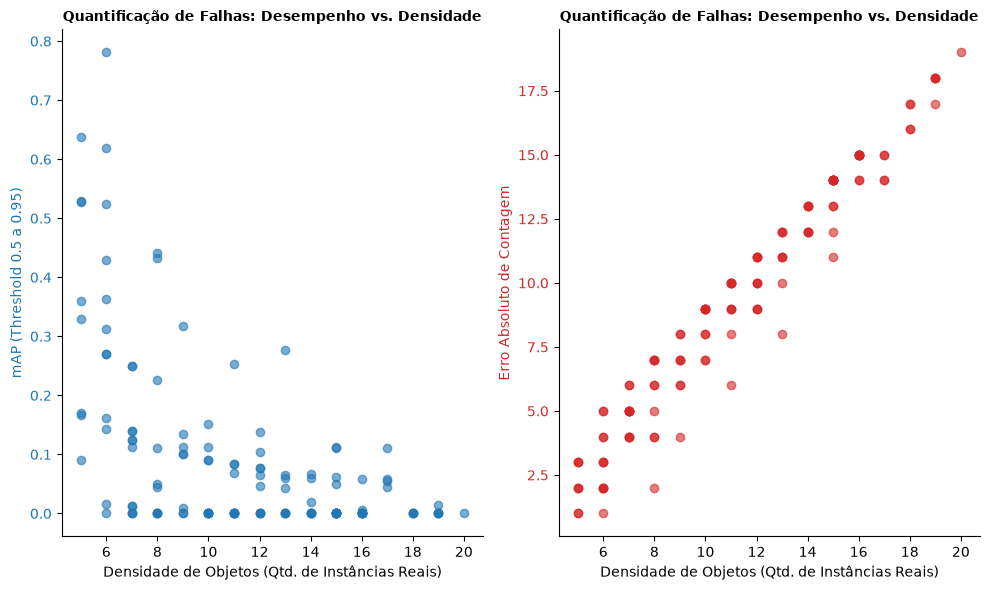

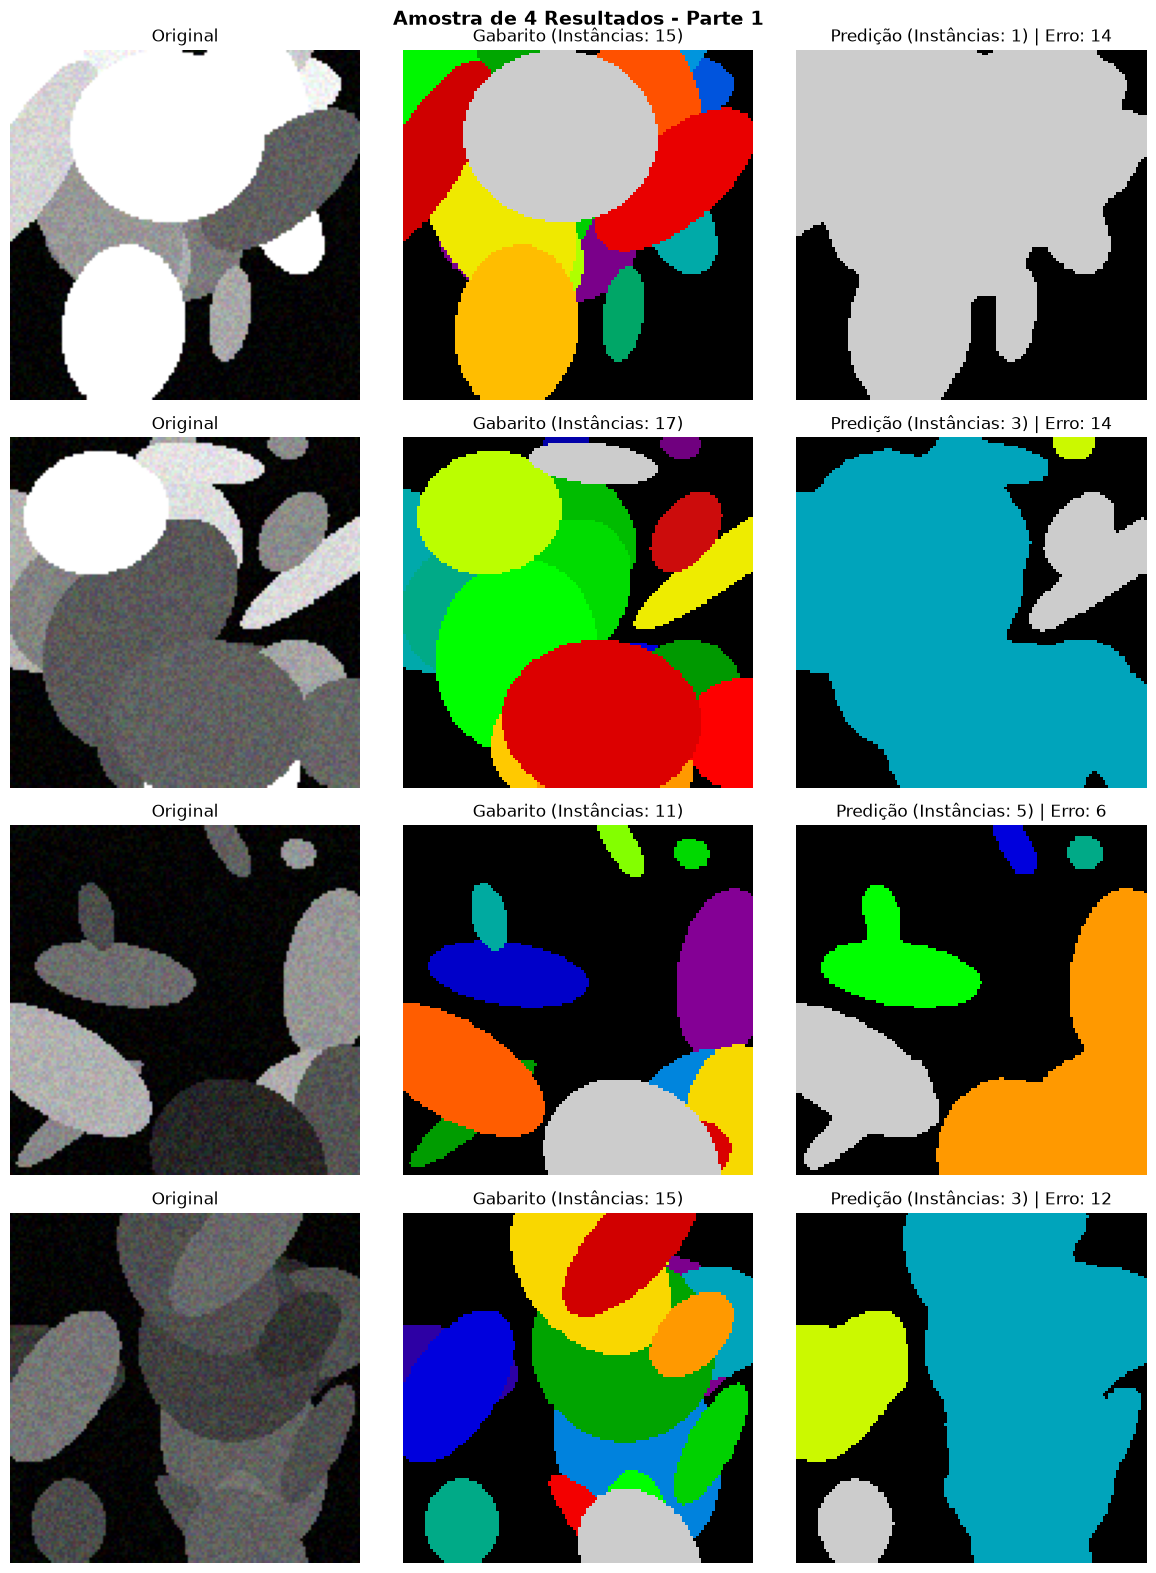

In [3]:
main(model_type='synthetic', part=1)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

## Parte 01

Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 0.6759 | IoU: 0.1269 | Dice: 0.2253
Epoch 2/10 | Loss: 0.3595 | IoU: 0.0000 | Dice: 0.0000
Epoch 3/10 | Loss: 0.2830 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 0.2258 | IoU: 0.1100 | Dice: 0.1982
Epoch 5/10 | Loss: 0.1805 | IoU: 0.5150 | Dice: 0.6799
Epoch 6/10 | Loss: 0.1495 | IoU: 0.6240 | Dice: 0.7685
Epoch 7/10 | Loss: 0.1258 | IoU: 0.6721 | Dice: 0.8039
Epoch 8/10 | Loss: 0.1159 | IoU: 0.6940 | Dice: 0.8194
Epoch 9/10 | Loss: 0.1091 | IoU: 0.7108 | Dice: 0.8310
Epoch 10/10 | Loss: 0.1042 | IoU: 0.7245 | Dice: 0.8403
Tempo de treinamento: 0.75 minutos
Média global mAP: 0.2361
Média global Erro Absoluto de Contagem: 25.4030


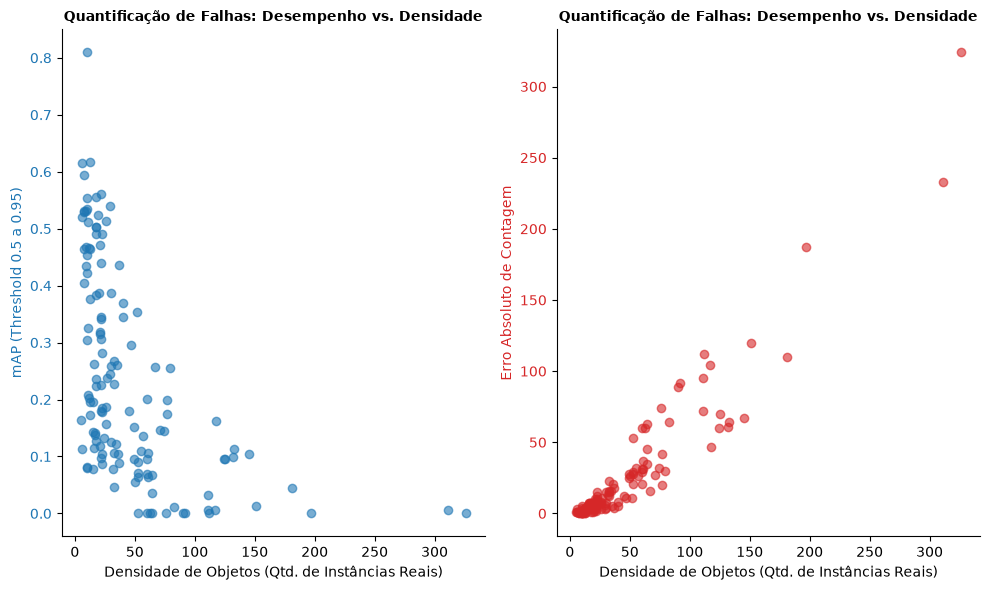

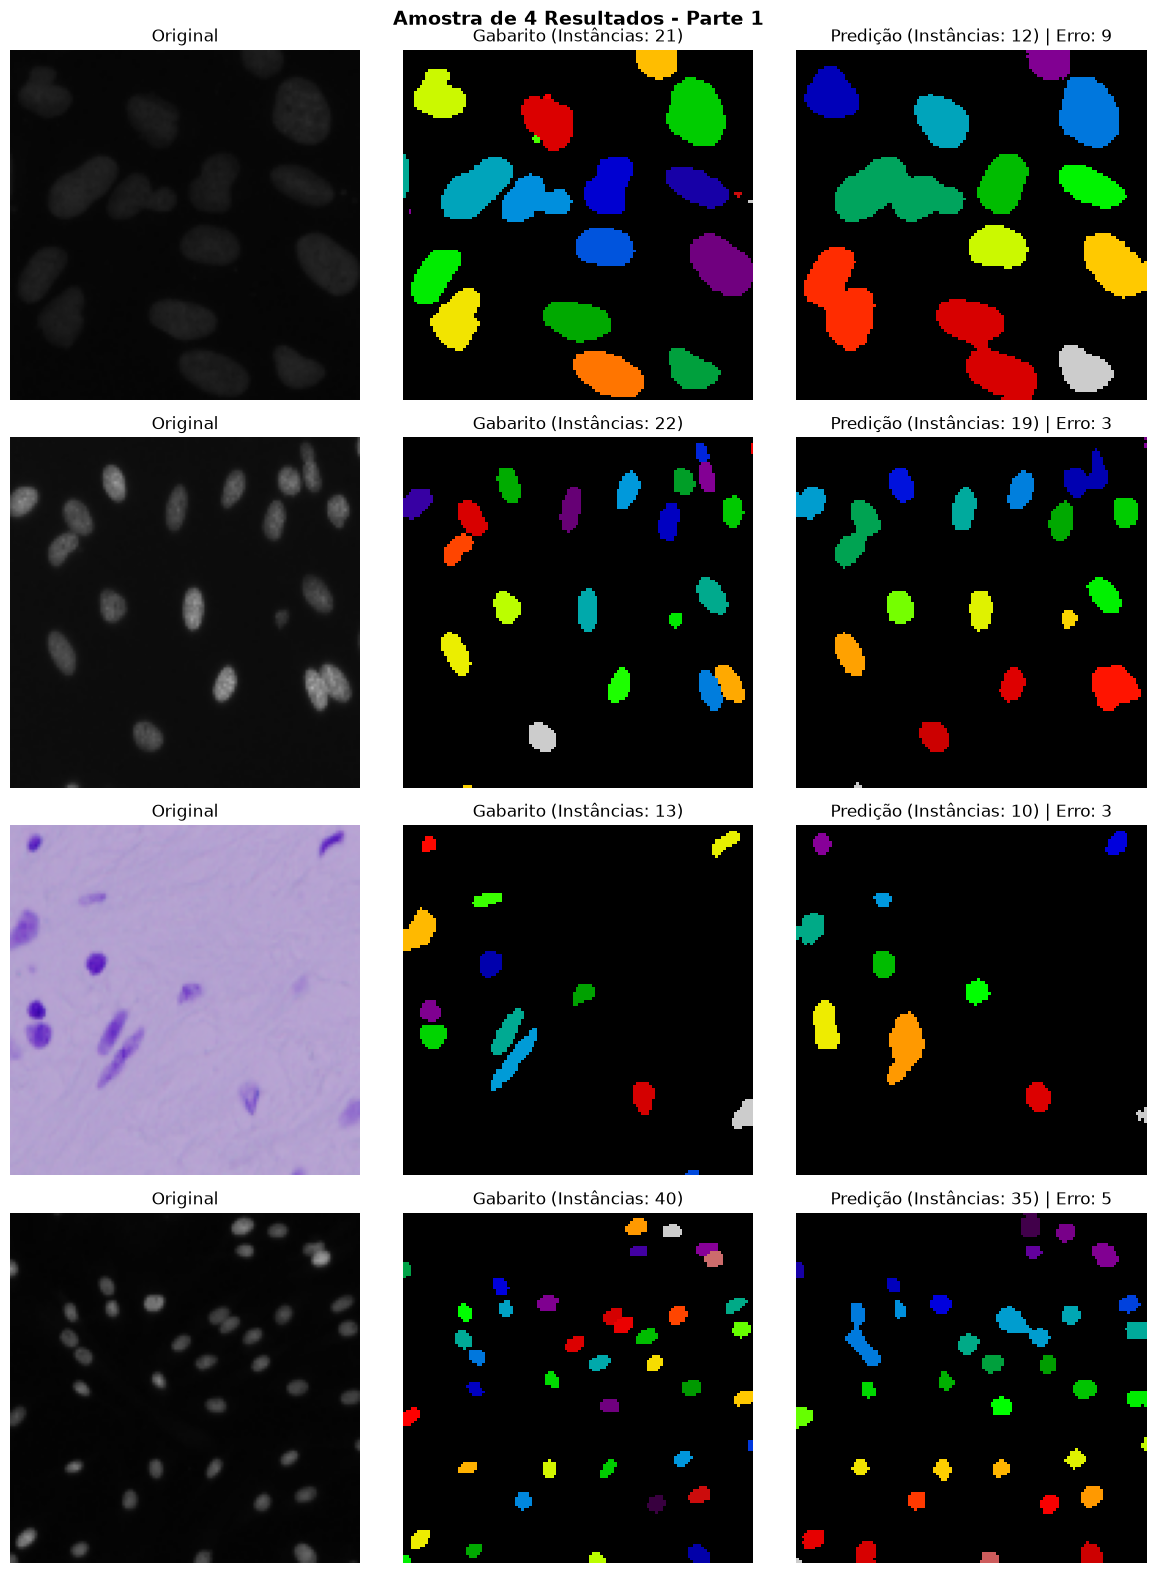

In [4]:
main(model_type='real', part=1)

## Parte 02

Parte 2 - Trilha B

In [5]:
main(model_type='real', part=2)

Treinando em: xpu
Batches por época: 34


c:\Users\luizb\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: An output with one or more elements was resized since it had shape [1, 11, 16], which does not match the required output shape [11, 16]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:38.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
c:\Users\luizb\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: An output with one or more elements was resized since it had shape [1, 8, 16], which does not match the required output shape [8, 16]. This behavior is deprecated, and in a future PyTorch release 

KeyboardInterrupt: 

## Parte 03

Eixos 1 e 3

## Parte 04

## Parte 05

## Parte 06